# Ex 1.7 Creating Network Visualizations

### 1. Install and import libraries 

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from pyvis.network import Network
import seaborn as sns
import pyvis 
import cdlib


### 2. Import country_relationships file 

In [2]:
# Import the country relationships file

df_relationships = pd.read_csv('20th-Century/country_relationships.csv', index_col = False)

In [3]:
df_relationships.head()

,Unnamed: 0,source,target
0,0,France,Russia
1,1,France,Russia
2,2,Germany,Russia
3,3,Germany,Russia
4,4,France,Russia


In [4]:
df_relationships = df_relationships.drop(columns =['Unnamed: 0'])

In [5]:
# It looks like I forgot the value column in yesterday's exercise.  I will add it now.

df_relationships["value"] = 1
df_relationships = df_relationships.groupby(["source","target"], sort=False, as_index=False).sum()

df_relationships.head(10)

,source,target,value
0,France,Russia,12
1,Germany,Russia,21
2,Germany,Italy,26
3,Austria,Germany,11
4,Germany,Spain,3
5,France,Spain,1
6,France,Poland,15
7,France,Germany,19
8,Germany,Poland,24
9,Estonia,Germany,5


In [6]:
# Export dataframe to csv file

df_relationships.to_csv('/Users/andymiller/20th-Century/country_relationships_2.csv')

### 3. Create network object

In [7]:
# Create a graph from a pandas dataframe

G = nx.from_pandas_edgelist(df_relationships, 
                            source = "source", 
                            target = "target", 
                            edge_attr = "value", 
                            create_using = nx.Graph())

### 4. Create Static Network Graph using NetworkX 

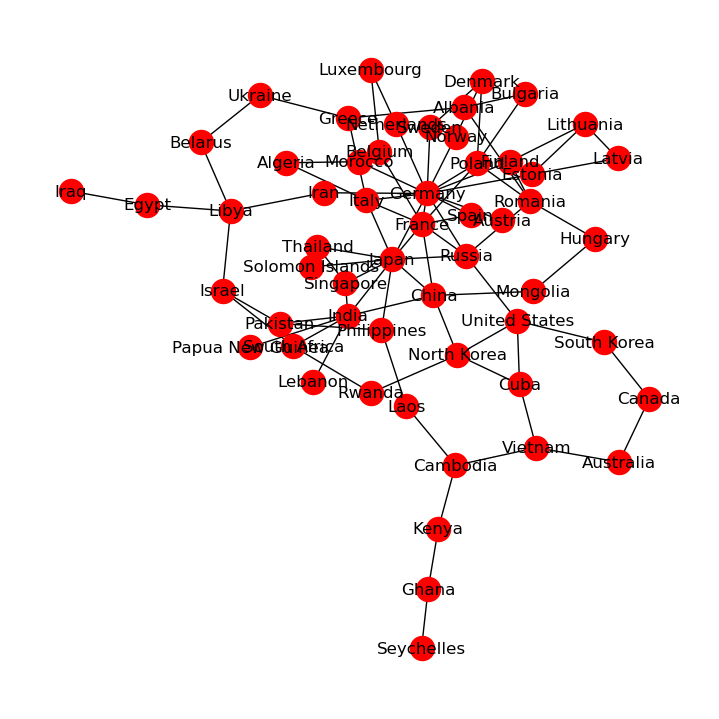

In [8]:
h = plt.figure(figsize = (7,7))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, with_labels = True, node_color = 'red', edge_cmap = plt.cm.Blues, pos = pos)
plt.show() 

In [9]:
h.savefig('networkx_plt_countries.png')

### 5. Build interactive network graph using pyvis

In [10]:
# Define net object

net = Network()
net = Network(notebook = True,width="900px", height="800px", bgcolor='#222222', font_color='white')

# Define nodes from the G object
node_degree = dict(G.degree)

# Setting up node size attributes
nx.set_node_attributes(G, node_degree, 'size')
net.from_nx(G)
net.show_buttons(filter_ = True)
net.repulsion()
net.show("countries.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


### 6. Apply Leiden Algorithm 

In [11]:
from cdlib import algorithms
coms = algorithms.leiden(G)

Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'graph_tool', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [13]:
type(coms)

cdlib.classes.node_clustering.NodeClustering

In [14]:
new_com = coms.to_node_community_map()

In [15]:
new_com

defaultdict(list,
            {'France': [0],
             'Russia': [0],
             'Germany': [0],
             'Italy': [0],
             'Austria': [0],
             'Spain': [0],
             'Poland': [0],
             'Denmark': [0],
             'Norway': [0],
             'Sweden': [0],
             'Netherlands': [0],
             'Luxembourg': [0],
             'Belgium': [0],
             'Morocco': [0],
             'Algeria': [0],
             'Japan': [1],
             'China': [1],
             'Thailand': [1],
             'Singapore': [1],
             'Philippines': [1],
             'Solomon Islands': [1],
             'India': [1],
             'Pakistan': [1],
             'Papua New Guinea': [1],
             'Lebanon': [1],
             'Libya': [2],
             'Egypt': [2],
             'Iraq': [2],
             'Israel': [2],
             'South Africa': [2],
             'Iran': [2],
             'Rwanda': [2],
             'North Korea': [3],
           

In [16]:
# Put the output from new_com into a dictionary

dict_com = {k:v[0] for k,v in new_com.items()}

In [17]:
dict_com

{'France': 0,
 'Russia': 0,
 'Germany': 0,
 'Italy': 0,
 'Austria': 0,
 'Spain': 0,
 'Poland': 0,
 'Denmark': 0,
 'Norway': 0,
 'Sweden': 0,
 'Netherlands': 0,
 'Luxembourg': 0,
 'Belgium': 0,
 'Morocco': 0,
 'Algeria': 0,
 'Japan': 1,
 'China': 1,
 'Thailand': 1,
 'Singapore': 1,
 'Philippines': 1,
 'Solomon Islands': 1,
 'India': 1,
 'Pakistan': 1,
 'Papua New Guinea': 1,
 'Lebanon': 1,
 'Libya': 2,
 'Egypt': 2,
 'Iraq': 2,
 'Israel': 2,
 'South Africa': 2,
 'Iran': 2,
 'Rwanda': 2,
 'North Korea': 3,
 'Cuba': 3,
 'United States': 3,
 'South Korea': 3,
 'Canada': 3,
 'Australia': 3,
 'Vietnam': 3,
 'Estonia': 4,
 'Latvia': 4,
 'Lithuania': 4,
 'Finland': 4,
 'Romania': 4,
 'Hungary': 4,
 'Mongolia': 4,
 'Laos': 5,
 'Cambodia': 5,
 'Kenya': 5,
 'Ghana': 5,
 'Seychelles': 5,
 'Albania': 6,
 'Greece': 6,
 'Ukraine': 6,
 'Belarus': 6,
 'Bulgaria': 6}

In [18]:
# Rerun network graph with the communities as an argument

nx.set_node_attributes(G, dict_com, 'group')
com_net = Network(notebook = True, width="1300px", height="700px", bgcolor='#222222', font_color='white')
com_net.from_nx(G)
com_net.show_buttons(filter_ = True)
com_net.repulsion()
com_net.show("country_communities_leiden.html")

Local cdn resources have problems on chrome/safari when used in jupyter-notebook. 


The communities do make historical sense considering the history of the 20th Century.  The countries that are clustered together have either geographical proximity, shared involvement in major conflicts or colonial or alliance ties.

The community in blue is dominated by western and central Europe which strongly reflects World Wars I and II with Germany appearing as a central and highly connected node which is to be expected given its role in both World Wars.

The orange community accurately captures Asia-Pacific wartime and post-colonial dynamics. Japan and China being central reflects imperial expansion, World War II in the Pacific.

The pink community including Iran, Libya, Egypt, Iraq, Israel, South Africa and Rwanda appear together due to 20th Century decolonization as well as regional wars.  South Africa and Rwanda appear due to late-century conflicts.  This group is linked due to shared conflict involvement rather that geographical proximity.

The red community of United States, North Korea, South Korea, Cuba, Vietnam, Canada and Australia are linked due to the Cold War tensions with the Korean War and Vietnam War also causing links.  Canada and Australia appear as US allies.

The green community features many countries from Eastern Europe.  These counties are clustered due to Soviet influence and Cold war-era geopolitics.

Finally the darker orange community consisting of Laos, Cambodia, Kenya, Ghana and Seychelles is clustered due to decolonization and late 20th century conflicts.

Several countries act as bridges between communities.  Germany connects Western Europe to Asia via Japan while Japan also links to East Asia.  The United States bridges Cold War Asia, Europe and the Americas while India connects Asia, the Middle East.  The 20th Century is therefore best understood as a connected global system rather than through separate isolated regions with wars and conflicts repeatedly pulling distant countries into shared historical narratives.


### 8. Centrality measures 

In [19]:
# Degree centrality

degree_dict = nx.degree_centrality(G)
degree_dict

{'France': 0.14545454545454545,
 'Russia': 0.09090909090909091,
 'Germany': 0.2545454545454545,
 'Italy': 0.09090909090909091,
 'Austria': 0.01818181818181818,
 'Spain': 0.03636363636363636,
 'Poland': 0.09090909090909091,
 'Estonia': 0.05454545454545454,
 'Latvia': 0.03636363636363636,
 'Lithuania': 0.05454545454545454,
 'Finland': 0.05454545454545454,
 'Denmark': 0.05454545454545454,
 'Norway': 0.03636363636363636,
 'Sweden': 0.03636363636363636,
 'Netherlands': 0.03636363636363636,
 'Luxembourg': 0.03636363636363636,
 'Belgium': 0.03636363636363636,
 'Albania': 0.05454545454545454,
 'Greece': 0.05454545454545454,
 'Ukraine': 0.03636363636363636,
 'Belarus': 0.03636363636363636,
 'Libya': 0.07272727272727272,
 'Egypt': 0.03636363636363636,
 'Iraq': 0.01818181818181818,
 'Japan': 0.18181818181818182,
 'Morocco': 0.03636363636363636,
 'Algeria': 0.03636363636363636,
 'China': 0.09090909090909091,
 'Thailand': 0.03636363636363636,
 'Singapore': 0.05454545454545454,
 'Philippines': 0.054

In [20]:
degree_df = pd.DataFrame(degree_dict.items(), columns=['countries','centrality'])

In [21]:
degree_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

In [25]:
degree_df.shape

(56, 2)

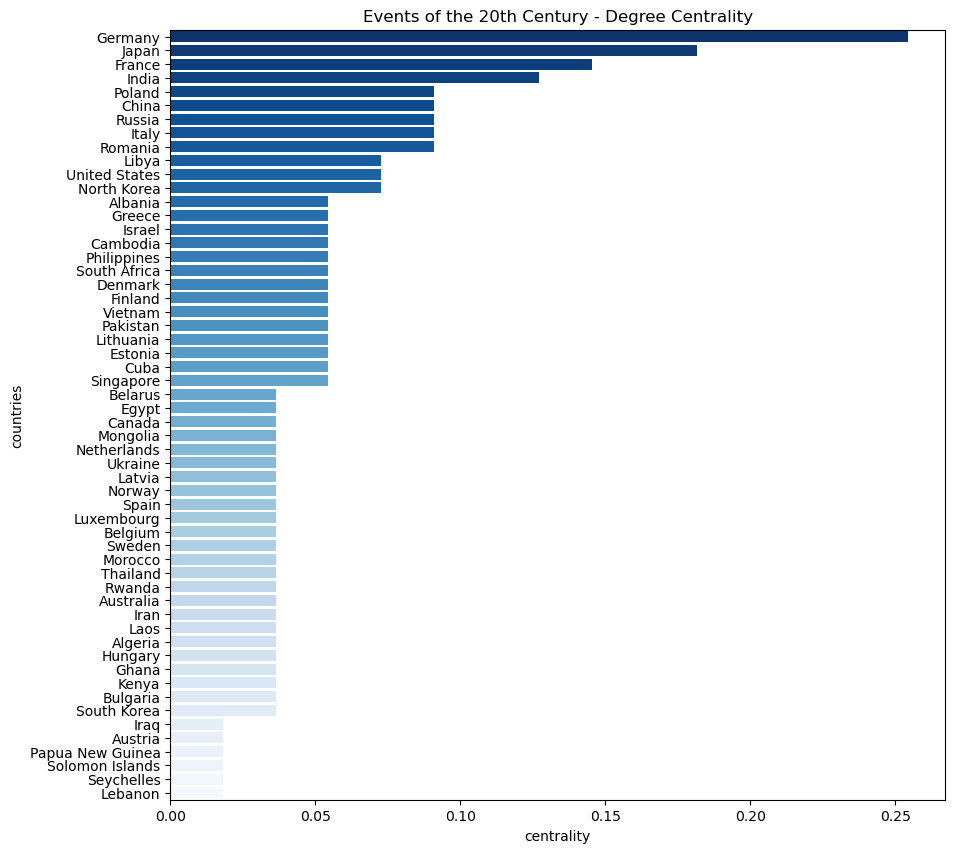

In [27]:
# Plot the degree centrality

plt.figure(figsize = (10, 10))
with sns.color_palette("Blues_r", n_colors= 56):
    sns.barplot(x = "centrality", y = "countries",
    saturation = 0.9, data = degree_df).set_title("Events of the 20th Century - Degree Centrality")

The bar chart shows that Germany has the highest degree of centrality which is not surprising given its role in both World Wars with neighbouring France in 3rd place. Next is Japan which is consistent with how it links Europe to East Asia and India has 4th highest degree of centrality which may well be due to the direct crown rule under the British until 1947 and then post-colonial tensions with Pakistan in the second half of the century.

In [31]:
# Closeness centrality

closeness_dict = nx.closeness_centrality(G)
closeness_df = pd.DataFrame(closeness_dict.items(), columns=['countries','centrality'])

In [32]:
closeness_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

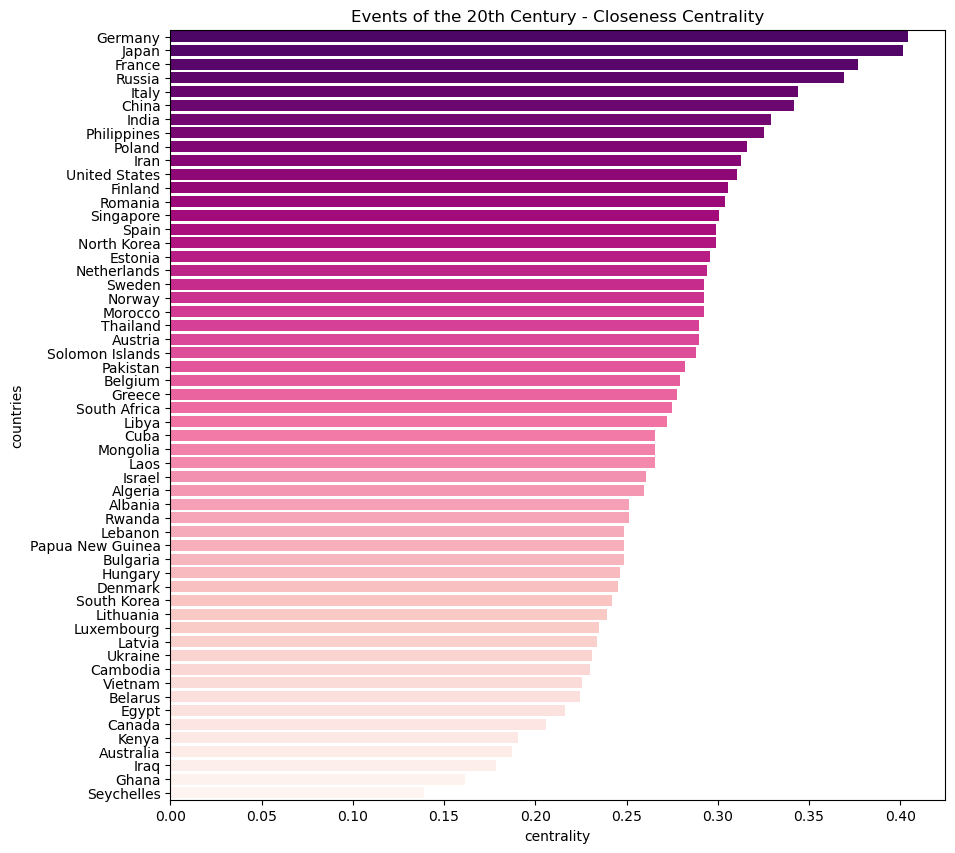

In [34]:
plt.figure(figsize = (10, 10))
with sns.color_palette("RdPu_r", 56):
    sns.barplot(x = "centrality", y = "countries",
    saturation = 0.9, data = closeness_df).set_title("Events of the 20th Century - Closeness Centrality")

The results for the closeness centrality look similar to the degree of centrality output in terms of the order of importance with countries such as Germany, Japan, France and Russia coming out on top.  Again these are the countries that are connected to many others and so therefore are most likely, in graph terms, to control, gather and spread information most efficiently though their connection in the network.

In [36]:
# Betweenness centrality

betweenness_dict = nx.betweenness_centrality(G)
betweennes_df = pd.DataFrame(betweenness_dict.items(), columns=['countries','centrality'])

In [37]:
betweennes_df.sort_values(by = ['centrality'], ascending=False, inplace = True)

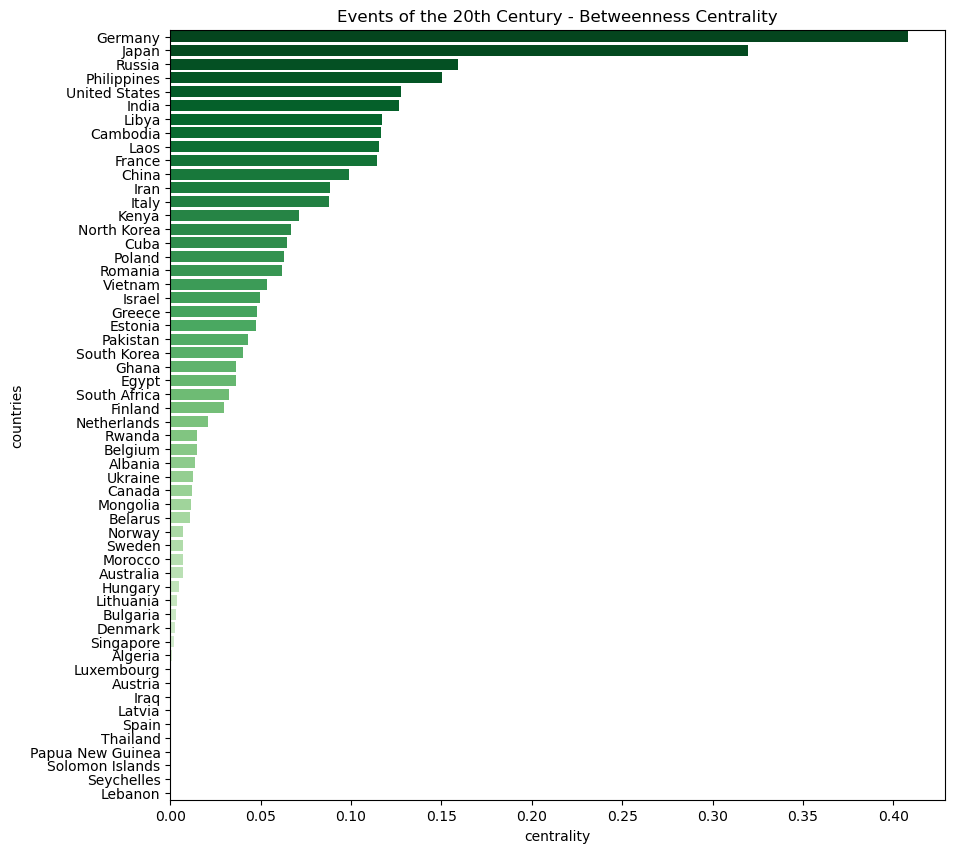

In [39]:
plt.figure(figsize = (10, 10))
with sns.color_palette("Greens_r", 56):
    sns.barplot(x = "centrality", y = "countries",
    saturation = 0.9, data = betweennes_df).set_title("Events of the 20th Century - Betweenness Centrality")

The betweenness measure output agrees with what the closeness centrality score established.  Germany is the most "influential" country with it's central role in both the first and second World Wars followed by Japan with its involvment in WWII and 20th Century imperial expansion. The top countries on this list are the ones that serve as a bridge from one part of the graph to another. The countries towards the bottom of the graph score very low on the scale suggesting that many countries interact with the main players only and not with each other.